Успешно сгенерировано 1000 точек. Данные сохранены в 'data.csv'


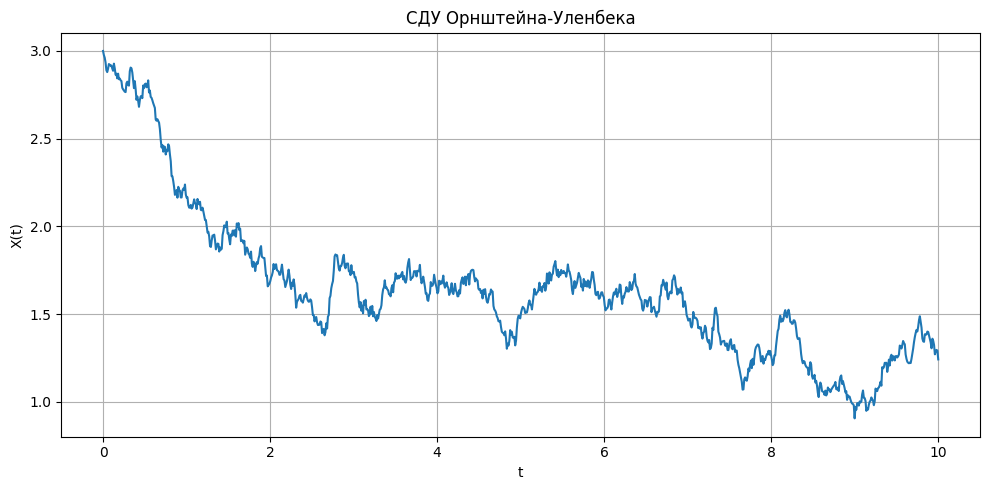

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

"""
    Генерирует данные для СДУ и сохраняет их в файл .csv
        theta (float): коэффициент скорости возврата к среднему
        mu (float): среднее значение, кк оторому стремится x
        sigma (float): волатильность (коэффициент шума)
        x0 (float): x0
        T (float): общее время
        dt (float): шаг по времени
        T / H = количество точек
"""

THETA_TRUE, MU_TRUE, SIGMA_TRUE = 0.7, 1.5, 0.3
X0, T, DT = 3.0, 10.0, 0.01

# график

def plot_process(t, x):
    plt.figure(figsize=(10, 5))
    plt.plot(t, x)
    plt.xlabel("t")
    plt.ylabel("X(t)")
    plt.title("СДУ Орнштейна-Уленбека")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Генератор

def generator(theta, mu, sigma, x0, T, dt, filename="data.csv"):
    
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x0
    
    # генерация СДУ Орнштейна-Уленбека по методу Эйлера-Маруямы 
    for i in range(1, N):
        dW = np.sqrt(dt) * np.random.normal(0, 1)
        X[i] = X[i-1] + theta * (mu - X[i-1]) * dt + sigma * dW
        
    # массивы идут в pandas
    table = pd.DataFrame({
        't': t,
        'X': X
    })
    
    table.to_csv(filename, index=False)
    print(f"Успешно сгенерировано {N} точек. Данные сохранены в '{filename}'")
    plot_process(t, X)

if __name__ == "__main__":
    generator(THETA_TRUE, MU_TRUE, SIGMA_TRUE, X0, T, DT)
    

Данные успешно загружены из data.csv. Найдено строк: 1000

--- Начало обучения ---
Эпоха :    0 | Loss: 2.807085 | Ошибка Theta: 85.86%, Ошибка Mu: 93.3999%, Ошибка Sigma: 66.9989%
Эпоха :  500 | Loss: 0.015330 | Ошибка Theta: 78.46%, Ошибка Mu: 82.1622%, Ошибка Sigma: 76.7499%
Эпоха : 1000 | Loss: 0.014687 | Ошибка Theta: 66.20%, Ошибка Mu: 47.2984%, Ошибка Sigma: 77.0312%
Эпоха : 1500 | Loss: 0.014201 | Ошибка Theta: 46.90%, Ошибка Mu: 23.0045%, Ошибка Sigma: 76.9494%
Эпоха : 2000 | Loss: 0.013275 | Ошибка Theta: 42.11%, Ошибка Mu: 19.5714%, Ошибка Sigma: 76.5491%
Эпоха : 2500 | Loss: 0.011829 | Ошибка Theta: 41.90%, Ошибка Mu: 18.8633%, Ошибка Sigma: 76.0876%
Эпоха : 3000 | Loss: 0.011160 | Ошибка Theta: 41.32%, Ошибка Mu: 18.0625%, Ошибка Sigma: 75.5711%
Эпоха : 3500 | Loss: 0.009940 | Ошибка Theta: 40.57%, Ошибка Mu: 17.0258%, Ошибка Sigma: 74.8856%
Эпоха : 4000 | Loss: 0.009041 | Ошибка Theta: 38.85%, Ошибка Mu: 15.7967%, Ошибка Sigma: 73.1353%
Эпоха : 4500 | Loss: 0.008919 | Оши

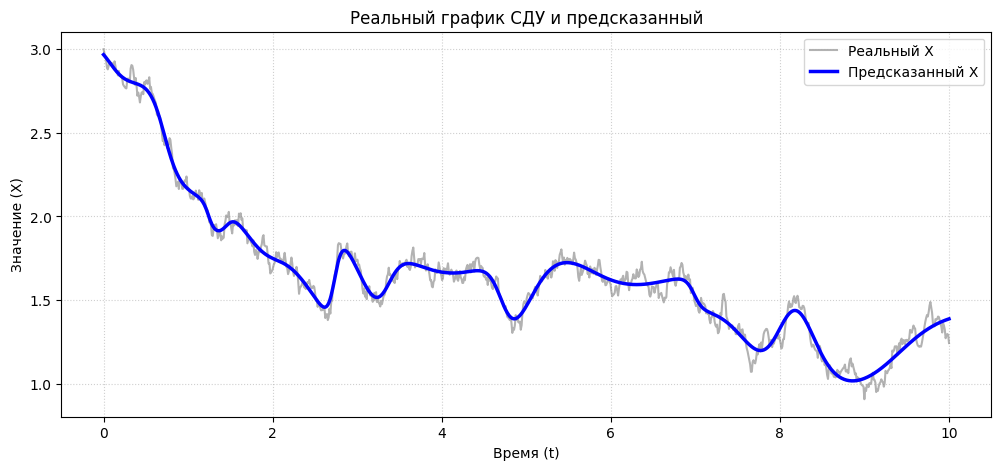

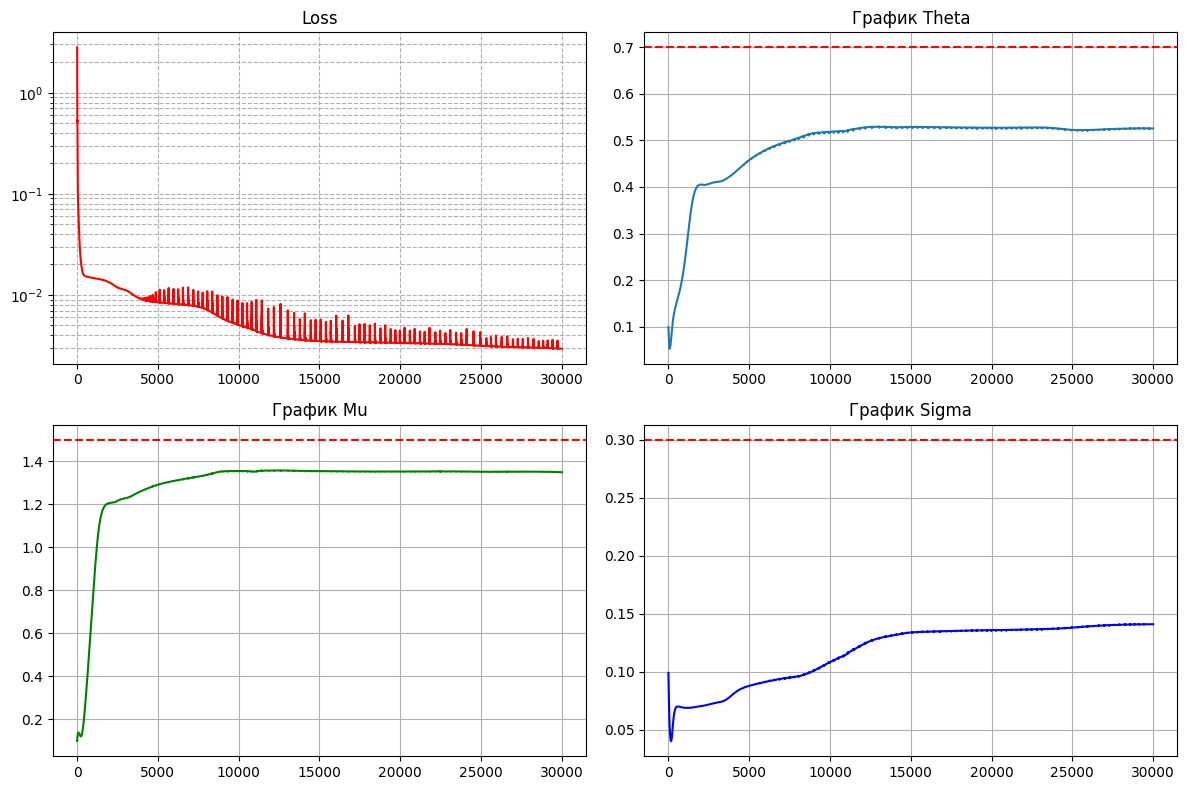

In [9]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Имя файла формата .csv
CSV_FILE = "data.csv"

# Значения параметров при генерации, для проверки качества модели
THETA_TRUE, MU_TRUE, SIGMA_TRUE = 0.7, 1.5, 0.3

# Количество вех для оптимизатора
ADAM_EPOCH = 30000

# Модель 

class PINN(nn.Module):
    def __init__(model):
        super().__init__()
        model.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        model.theta_pred = nn.Parameter(torch.tensor([0.1], dtype=torch.float32, requires_grad=True))
        model.mu_pred = nn.Parameter(torch.tensor([0.1], dtype=torch.float32, requires_grad=True))
        model.sigma_pred = nn.Parameter(torch.tensor([0.1], dtype=torch.float32, requires_grad=True))
        
    def forward(model, t):
        return model.net(t)

# Загрузка и обработка данных

try:
    table = pd.read_csv(CSV_FILE)
    print(f"Данные успешно загружены из {CSV_FILE}. Найдено строк: {len(table)}")
except FileNotFoundError:
    print(f"Ошибка! Файл {CSV_FILE} не найден. Сначала запустите generate_data_csv.py")
    exit()

t_data = torch.tensor(table['t'].values, dtype=torch.float32).view(-1, 1)
X_data = torch.tensor(table['X'].values, dtype=torch.float32).view(-1, 1)

# вектора точек 

T_MAX = t_data.max().item()
t_physics = torch.linspace(0, T_MAX, 200, dtype=torch.float32).view(-1, 1)

# Оптимизатор и функция loss

pinn = PINN()

optimizer_adam = torch.optim.Adam(list(pinn.parameters()), lr=0.001)

history_loss = []
history_theta, history_mu, history_sigma = [], [], []

def total_loss():
    # конечные разности
    X_pred_data = pinn(t_data)
    loss_data = torch.mean((X_pred_data - X_data) ** 2)
    dt = (t_physics[-1] - t_physics[0]) / (len(t_physics) - 1)
    X_phys = pinn(t_physics)
    X_current = X_phys[:-1]
    X_next = X_phys[1:]
    x_theta_mu = pinn.theta_pred * (pinn.mu_pred - X_current) * dt
    dx = X_next - X_current
    loss_x_theta_mu = torch.mean((dx - x_theta_mu) ** 2)
    res = dx - loss_x_theta_mu
    loss_sigma = torch.mean((res ** 2) - (pinn.sigma_pred ** 2) * dt) ** 2
    return loss_data + 0.7 * loss_x_theta_mu + 0.3 * loss_sigma

# Обучение

print("\n--- Начало обучения ---")
for epoch in range(ADAM_EPOCH+1):
    optimizer_adam.zero_grad()
    loss = total_loss()
    loss.backward()
    optimizer_adam.step()
    
    history_loss.append(loss.item())
    history_theta.append(pinn.theta_pred.item())
    history_mu.append(pinn.mu_pred.item())
    history_sigma.append(pinn.sigma_pred.item())
    
    if epoch % 500 == 0:
        err_theta = abs(pinn.theta_pred.item() - THETA_TRUE) / THETA_TRUE * 100
        err_mu = abs(pinn.mu_pred.item() - MU_TRUE) / MU_TRUE * 100
        err_sigma = abs(pinn.sigma_pred.item() - SIGMA_TRUE) / SIGMA_TRUE * 100
        print(f"Эпоха : {epoch:4d} | Loss: {loss.item():.6f} | Ошибка Theta: {err_theta:.2f}%, Ошибка Mu: {err_mu:.4f}%, Ошибка Sigma: {err_sigma:.4f}%")
print("\n--- Конец обучения ---")
print("\nИтоговые значения:")
print(f"Эпоха : {epoch:4d} | Loss: {loss.item():.6f} |  Theta: {pinn.theta_pred.item():.4f},  Mu: {pinn.mu_pred.item():.4f}, Sigma: {pinn.sigma_pred.item():.4f}")

# картинки

pinn.eval()
with torch.no_grad():
    X_pred_pinn = pinn(t_data).numpy()

plt.figure(figsize=(12, 5))
plt.plot(t_data.numpy(), X_data.numpy(), color='gray', alpha=0.6, label='Реальный X')
plt.plot(t_data.numpy(), X_pred_pinn, color='blue', linewidth=2.5, label='Предсказанный X')
plt.title('Реальный график СДУ и предсказанный')
plt.xlabel('Время (t)')
plt.ylabel('Значение (X)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best')
plt.savefig('pinn_x(t).png', dpi=300, bbox_inches='tight')
print("График сохранен под именем pinn_x(t).png")

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(history_loss, color='red', label='Loss')
plt.yscale('log')
plt.title('Loss')
plt.grid(True, which="both", ls="--")
plt.subplot(2, 2, 2)
plt.plot(history_theta, label='theta предсказанная')
plt.axhline(y=THETA_TRUE, color='r', linestyle='--')
plt.title('График Theta')
plt.grid(True)
plt.subplot(2, 2, 3)
plt.plot(history_mu, label='mu предсказанная', color='green')
plt.axhline(y=MU_TRUE, color='r', linestyle='--')
plt.title('График Mu')
plt.grid(True)
plt.subplot(2, 2, 4)
plt.plot(history_sigma, label='sigma предсказанная', color='blue')
plt.axhline(y=SIGMA_TRUE, color='r', linestyle='--')
plt.title('График Sigma')
plt.grid(True)
plt.tight_layout()
plt.savefig('pinn.png', dpi=300, bbox_inches='tight')
print("Графики сохранены под именем pinn.png")
plt.show()